## Dos tipos de zonas

**PolygonZone** — como un tapete contador:
detecta si un objeto está parado sobre él en este frame exacto.
Muestra cuántos objetos hay dentro en cada momento.

**LineZone** — como un torniquete:
registra cada vez que un objeto lo cruza (en cualquier dirección).
Acumula el conteo a lo largo de todo el video.

```
PolygonZone: ¿cuántos objetos hay AHORA en esta área?
LineZone:    ¿cuántos objetos han CRUZADO esta línea en total?
```

In [2]:
%pip install supervision ultralytics trackers
%pip install -q rfdetr "trackers==2.4.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import supervision as sv
from ultralytics import YOLO
from trackers import ByteTrackTracker
import cv2
import numpy as np

model = YOLO('yolov8n.pt')
tracker = ByteTrackTracker()
box_annotator = sv.BoxAnnotator()

video_info = sv.VideoInfo.from_video_path('people-walking.mp4')
print(f'Resoucion: {video_info.width} x {video_info.height}')


Resoucion: 1920 x 1080


# Definir la zona poligonal
El poligono es solo una lista de verices (x, y) en pixeles. Puedes dibujar cualquier forma - rectangulos, triangulos, formas irregulares

In [4]:
from numpy import half
half_width = video_info.width // 2
half_height = video_info.height // 2

LEFT_POLYGON = np.array([
    [0, half_height],
    [half_width, half_height],
    [half_width, video_info.height],
    [0, video_info.height]
])

zone = sv.PolygonZone(polygon = LEFT_POLYGON)

# Polygon Zone Annotator

- Zone: PolygonZone
- color: Color
- thickness: int
- text_color: Color
- text_scale: float
- text_thickness: int
- text_padding: int
- font: int
- center = Tuple[int, int]

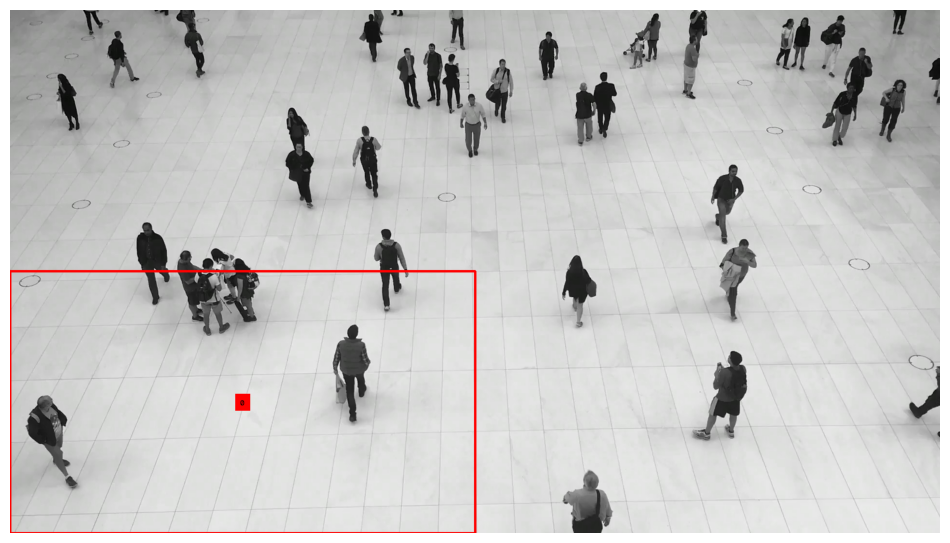

In [5]:
polygon_zone_annotator = sv.PolygonZoneAnnotator(zone = zone, color = sv.Color.RED, thickness = 4)
cap = cv2.VideoCapture('people-walking.mp4')
ret, first_frame = cap.read()
cap.release()

annotated = polygon_zone_annotator.annotate(scene = first_frame.copy())
sv.plot_image(annotated)

# Procesar video con conteo por zona

In [6]:
from supervision import detection
from supervision.detection.tools import polygon_zone
label_annotator = sv.LabelAnnotator()
tracker = ByteTrackTracker()

def zone_callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update(detections)

    in_zone = zone.trigger(detections = detections)
    detections_in_zone = detections[in_zone]

    labels = [f"ID: {tid}" for tid in detections_in_zone.tracker_id]

    annotated = box_annotator.annotate(scene = frame.copy(), detections=detections_in_zone)
    annotated = label_annotator.annotate(scene = annotated, detections=detections_in_zone, labels = labels)
    return polygon_zone_annotator.annotate(scene = annotated)

sv.process_video(
    source_path='people-walking.mp4',
    target_path='in-zone-people-walking.mp4',
    callback = zone_callback,
    show_progress= True
)

Processing video:   0%|          | 0/341 [00:00<?, ?it/s]


0: 384x640 37 persons, 2 birds, 33.1ms
Speed: 10.3ms preprocess, 33.1ms inference, 13.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 38 persons, 3 birds, 4.9ms
Speed: 1.8ms preprocess, 4.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 3 birds, 4.5ms
Speed: 1.0ms preprocess, 4.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 37 persons, 3 birds, 4.5ms
Speed: 1.0ms preprocess, 4.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 4.5ms
Speed: 1.6ms preprocess, 4.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 38 persons, 2 birds, 5.0ms
Speed: 1.0ms preprocess, 5.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 4.2ms
Speed: 1.0ms preprocess, 4.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 6.4ms
Speed: 1.1ms

# LINE ZONE - Conteo de cruces

LineZone funciona diferente a PolygonZone:
no cuenta presencia instantánea sino cruces acumulados a lo largo del video.
La API también es diferente: usa `in_count`/`out_count` en lugar de `current_count`.

- start = Point
- end = Point
- triggering_anchors = List[Position]

In [7]:
line_start = sv.Point(x = 0, y = half_height)
line_end = sv.Point(x = video_info.width, y = half_height)

line_zone = sv.LineZone(start = line_start, end = line_end, triggering_anchors=[sv.Position.TOP_LEFT])
tracker = ByteTrackTracker()

## Line Zone Annotator

- thickness = int
- color = Color
- text_thickness = int
- text_color = Color
- text_scale = float
- text_offset = float
- text_padding = int
- custom_in_text = str
- custom_out_text = str
- display_in_count = bool
- display_out_count = bool
- display_text_box = bool
- text_orient_to_line = bool
- text_centered = bool

In [9]:
line_zone_annotator = sv.LineZoneAnnotator(
    thickness=4,
    text_scale = 1.5,
    custom_in_text = "In Counter: ",
    custom_out_text="Out Counter: "
)

def line_callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update(detections)

    line_zone.trigger(detections = detections)

    annotated = box_annotator.annotate(scene = frame.copy(), detections=detections)
    return line_zone_annotator.annotate(frame = annotated, line_counter=line_zone)

sv.process_video(
    source_path='people-walking.mp4',
    target_path = 'line-zone.people-walking.mp4',
    callback=line_callback,
    show_progress=True
)

Processing video:   0%|          | 0/341 [00:00<?, ?it/s]


0: 384x640 37 persons, 2 birds, 5.8ms
Speed: 5.9ms preprocess, 5.8ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 38 persons, 3 birds, 10.4ms
Speed: 2.0ms preprocess, 10.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 3 birds, 9.8ms
Speed: 1.3ms preprocess, 9.8ms inference, 5.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 37 persons, 3 birds, 4.6ms
Speed: 1.4ms preprocess, 4.6ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 6.2ms
Speed: 1.4ms preprocess, 6.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 38 persons, 2 birds, 4.7ms
Speed: 1.1ms preprocess, 4.7ms inference, 6.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 6.8ms
Speed: 1.4ms preprocess, 6.8ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 3.9ms
Speed: 1.2ms p

## INFERENCE SLICER

Especially useful when your image is large and the objects you want to detect are small relative to the full image.

- slicer_wh = Tuple[int, int]
- overlap_ratio_wh = Tuple[float, float]
- iou_threshold = Optional[float]
- callback = Callable
- thread_workers = int

In [10]:
def slicer_callback(image_slice: np.ndarray) -> sv.Detections:
    results = model(image_slice)[0]
    return sv.Detections.from_ultralytics(results)

tracker = ByteTrackTracker()

def video_slicer_callback(frame: np.ndarray, _: int) -> np.ndarray:
    slicer = sv.InferenceSlicer(callback=slicer_callback)
    detections = slicer(frame)
    detections = tracker.update(detections)
    return box_annotator.annotate(scene = frame.copy(), detections=detections)

sv.process_video(
    source_path='people-walking.mp4',
    target_path='slicer-people-walking.mp4',
    callback=video_slicer_callback,
    show_progress=True
)

Processing video:   0%|          | 0/341 [00:00<?, ?it/s]


0: 640x640 11 persons, 1 backpack, 7.0ms
Speed: 7.0ms preprocess, 7.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 16 persons, 1 handbag, 6.4ms
Speed: 1.6ms preprocess, 6.4ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 15 persons, 1 backpack, 5.9ms
Speed: 1.8ms preprocess, 5.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 16 persons, 7.5ms
Speed: 1.7ms preprocess, 7.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 6 persons, 5.4ms
Speed: 2.1ms preprocess, 5.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 persons, 4.5ms
Speed: 1.6ms preprocess, 4.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 persons, 6.3ms
Speed: 1.4ms preprocess, 6.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 3 persons, 4.7ms
Speed: 1.4ms preprocess, 4.7ms inference, 1.1ms postproce

## Detection Smoother

A utility class for smoothing detections over multiple frames in video tracking. It maintains a history of detections for each track and provides smoothed predictions based on these histories.

- length = int

In [12]:
tracker = ByteTrackTracker()

box_annotator = sv.BoxAnnotator()
smoother = sv.DetectionsSmoother(length = 5)

def smoother_callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update(detections)
    detections = smoother.update_with_detections(detections)

    return box_annotator.annotate(scene = frame.copy(), detections=detections)

sv.process_video(
    source_path='people-walking.mp4',
    target_path='smoother-people-walking.mp4',
    callback=smoother_callback,
    show_progress=True
)

Processing video:   0%|          | 0/341 [00:00<?, ?it/s]


0: 384x640 37 persons, 2 birds, 9.4ms
Speed: 5.7ms preprocess, 9.4ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 38 persons, 3 birds, 22.0ms
Speed: 1.3ms preprocess, 22.0ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 35 persons, 3 birds, 9.4ms
Speed: 2.3ms preprocess, 9.4ms inference, 6.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 37 persons, 3 birds, 5.4ms
Speed: 1.7ms preprocess, 5.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 4.2ms
Speed: 1.5ms preprocess, 4.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 38 persons, 2 birds, 16.9ms
Speed: 1.4ms preprocess, 16.9ms inference, 5.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 8.7ms
Speed: 2.2ms preprocess, 8.7ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 36 persons, 2 birds, 4.0ms
Speed: 1.5ms